# Imports

In [42]:
from nb_utils import set_root
PROJECT_DIR = set_root(1)

In [43]:
import numpy as np
import matplotlib.pyplot as plt

In [44]:
from PIL import Image
from scipy.signal import convolve2d

# Methods

In [45]:
def load_image(image_path):
    image = Image.open(image_path).convert('L')
    return np.array(image)

def apply_fourier_transform(image):
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1)
    return magnitude_spectrum

def plot_images(dict_content: dict[str], figsize: tuple[int, int] = (12, 6), with_ax: bool=False) -> tuple[plt.Figure, np.ndarray]:
    fig, ax = plt.subplots(len(dict_content), 2, figsize=figsize)

    if len(dict_content) == 1:
        ax = np.expand_dims(ax, axis=0)

    for idx, (key, value) in enumerate(dict_content.items()):
        ax[idx, 0].set_title("Imagem Original")
        ax[idx, 0].imshow(value["original"]["img"], **value["original"]["args"])
        ax[idx, 0].axis('off')

        ax[idx, 1].set_title("Transformada")
        ax[idx, 1].imshow(value["transformada"]["img"], **value["transformada"]["args"])
        if not with_ax:
            ax[idx, 1].axis('off')

    fig.tight_layout()
    plt.show()
    return fig, ax

In [46]:
def apply_convolution(matrix, kernel):
    """
    Aplica a convolução entre uma matriz e um kernel.
    
    Args:
        matrix (np.ndarray): Matriz original.
        kernel (np.ndarray): Kernel para convolução.
    
    Returns:
        np.ndarray: Resultado da convolução.
    """
    result = convolve2d(matrix, kernel, mode='same', boundary='fill', fillvalue=0)
    return result

def plot_matrices(original, convolved, figsize=(10, 5)):
    """
    Plota a matriz original e a matriz convoluída lado a lado.
    
    Args:
        original (np.ndarray): Matriz original.
        convolved (np.ndarray): Matriz convoluída.
    """
    fig, axes = plt.subplots(1, len(convolved) + 1, figsize=figsize)

    axes[0].imshow(original, cmap='gray')
    axes[0].set_title("Matriz Original")
    axes[0].axis('off')

    for idx, (key, content) in enumerate(convolved.items()):

        axes[idx + 1].imshow(content, cmap='gray')
        axes[idx + 1].set_title(key)
        axes[idx + 1].axis('off')

    fig.tight_layout()
    
    return fig, axes

# Parameters

In [47]:
path_assets = PROJECT_DIR / 'assets'

# Questão 01

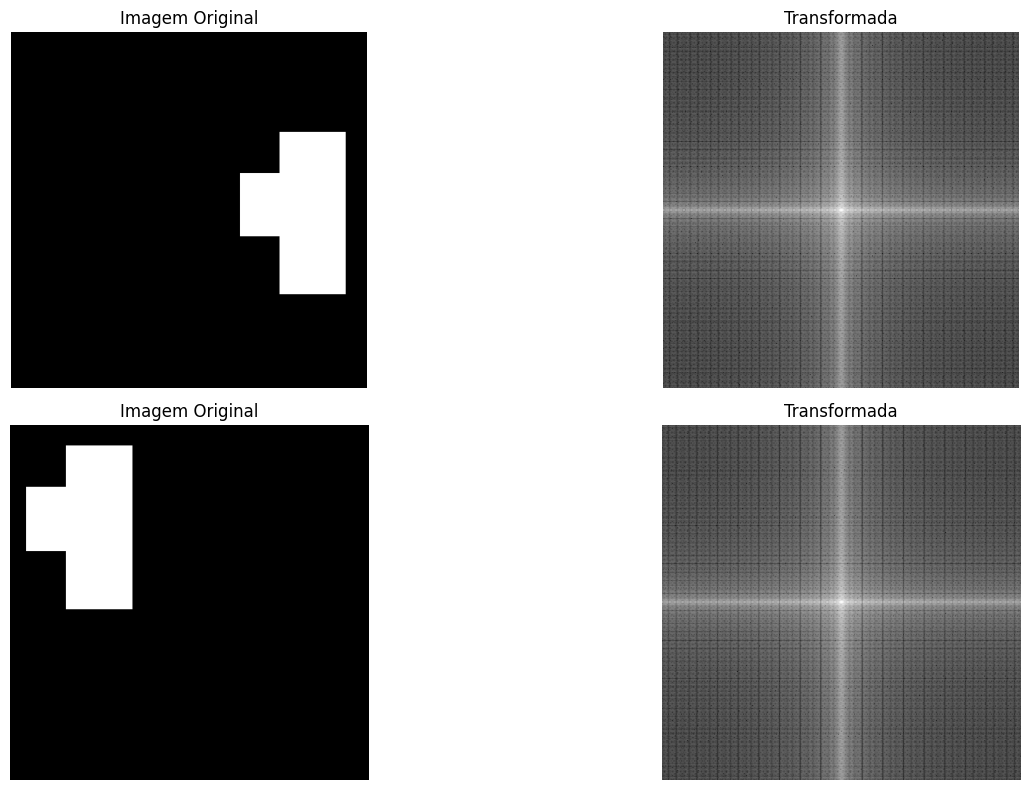

In [48]:


q1_i1 = load_image(path_assets / "atv02-q01-03.png")
q1_i2 = load_image(path_assets / "atv02-q01-04.png")

i1_magnitude_spectrum = apply_fourier_transform(q1_i1)
i2_magnitude_spectrum = apply_fourier_transform(q1_i2)

fig_q1_i1, ax_q1_i1 = plot_images(
    {
        "img_1": {
            "original": {
                "img": q1_i1,
                "args": {"cmap": 'gray'}
            },
            "transformada": {
                "img": i1_magnitude_spectrum,
                "args": {"cmap": 'gray'}
            }
        },
        "img_2": {
            "original": {
                "img": q1_i2,
                "args": {"cmap": 'gray'}
            },
            "transformada": {
                "img": i2_magnitude_spectrum,
                "args": {"cmap": 'gray'}
            }
        }
    },
    figsize=(16, 8)
)
fig_q1_i1.savefig(path_assets / "atv02-q01-05.png", dpi=400, bbox_inches='tight')


# Questão 02

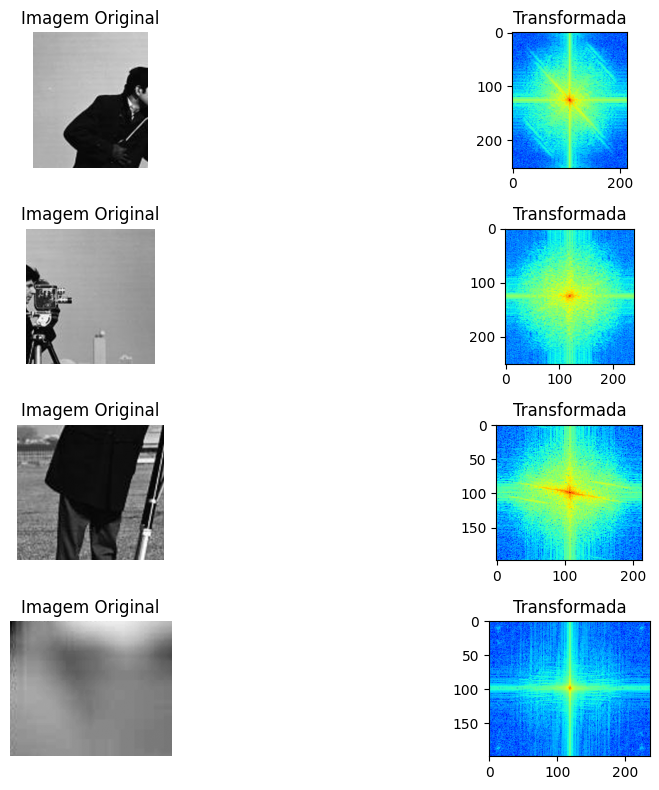

In [49]:
q2_imgs = {
    f"q0{k}": load_image(path_assets / f"atv02-q02-0{k}.png") for k in range(3, 7)
}

transformadas = {
    key: apply_fourier_transform(value) for key, value in q2_imgs.items()
}

fig_q2_i1, ax_q2_i1 = plot_images(
    {
        key: {
            "original": {
                "img": q2_imgs[key],
                "args": {"cmap": 'gray'}
            },
            "transformada": {
                "img": value,
                "args": {"cmap": 'jet'}
            }
        }
        for key, value in transformadas.items()
    },
    figsize=(12, 8),
    with_ax=True
)
fig_q2_i1.savefig(path_assets / "atv02-q02-07.png", dpi=400, bbox_inches='tight')


# Questão 04

In [50]:
f = (1 / 9) * np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])

h = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

In [51]:
result_fh = convolve2d(f, h, mode='full', boundary='fill', fillvalue=0)
result_hf = convolve2d(h, f, mode='full', boundary='fill', fillvalue=0)

In [52]:
print("f * h: ")
print(result_fh)
print()
print("h * f:")
print(result_hf)
print()
print("{ f * h == h * f }: ", "{", np.array_equal(result_fh, result_hf), "}")

f * h: 
[[-0.11111111 -0.11111111  0.          0.11111111  0.11111111]
 [-0.22222222 -0.22222222  0.          0.22222222  0.22222222]
 [-0.33333333 -0.33333333  0.          0.33333333  0.33333333]
 [-0.22222222 -0.22222222  0.          0.22222222  0.22222222]
 [-0.11111111 -0.11111111  0.          0.11111111  0.11111111]]

h * f:
[[-0.11111111 -0.11111111  0.          0.11111111  0.11111111]
 [-0.22222222 -0.22222222  0.          0.22222222  0.22222222]
 [-0.33333333 -0.33333333  0.          0.33333333  0.33333333]
 [-0.22222222 -0.22222222  0.          0.22222222  0.22222222]
 [-0.11111111 -0.11111111  0.          0.11111111  0.11111111]]

{ f * h == h * f }:  { True }


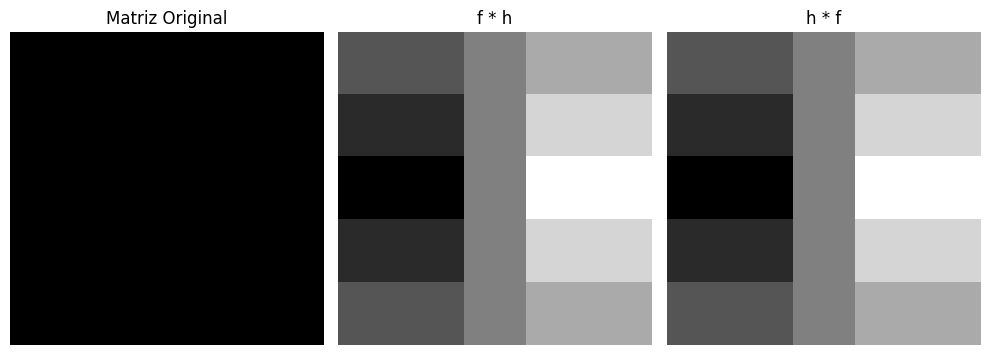

In [53]:
fig_q4, ax_q4 = plot_matrices(
    f,
    {
        "f * h": result_fh,
        "h * f": result_hf
    }
)
fig_q4.savefig(path_assets / "atv02-q04-03.png", dpi=400, bbox_inches='tight')

# Questão 05

In [54]:
B = (1 / 9) * np.array(
    [
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ]
)

In [55]:
B2 = convolve2d(B, B, mode='full', boundary='fill', fillvalue=0)
print("B * B: \n", B2)

B * B: 
 [[0.01234568 0.02469136 0.03703704 0.02469136 0.01234568]
 [0.02469136 0.04938272 0.07407407 0.04938272 0.02469136]
 [0.03703704 0.07407407 0.11111111 0.07407407 0.03703704]
 [0.02469136 0.04938272 0.07407407 0.04938272 0.02469136]
 [0.01234568 0.02469136 0.03703704 0.02469136 0.01234568]]


In [56]:
B3 = convolve2d(B2, B, mode='full', boundary='fill', fillvalue=0)
print("(B * B) * B: \n", B3)

(B * B) * B: 
 [[0.00137174 0.00411523 0.00823045 0.00960219 0.00823045 0.00411523
  0.00137174]
 [0.00411523 0.01234568 0.02469136 0.02880658 0.02469136 0.01234568
  0.00411523]
 [0.00823045 0.02469136 0.04938272 0.05761317 0.04938272 0.02469136
  0.00823045]
 [0.00960219 0.02880658 0.05761317 0.06721536 0.05761317 0.02880658
  0.00960219]
 [0.00823045 0.02469136 0.04938272 0.05761317 0.04938272 0.02469136
  0.00823045]
 [0.00411523 0.01234568 0.02469136 0.02880658 0.02469136 0.01234568
  0.00411523]
 [0.00137174 0.00411523 0.00823045 0.00960219 0.00823045 0.00411523
  0.00137174]]


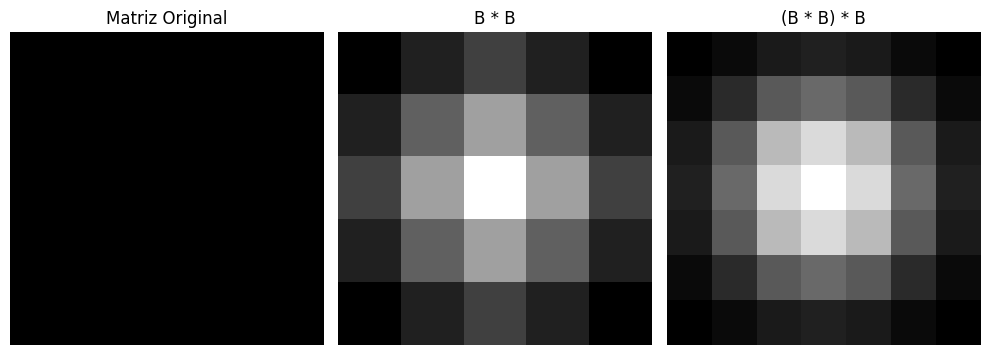

In [57]:
fig_q5_i1, ax_q5_i1 = plot_matrices(
    B,
    {
        "B * B": B2,
        "(B * B) * B": B3
    }
)
fig_q5_i1.savefig(path_assets / "atv02-q05-03.png", dpi=400, bbox_inches='tight')

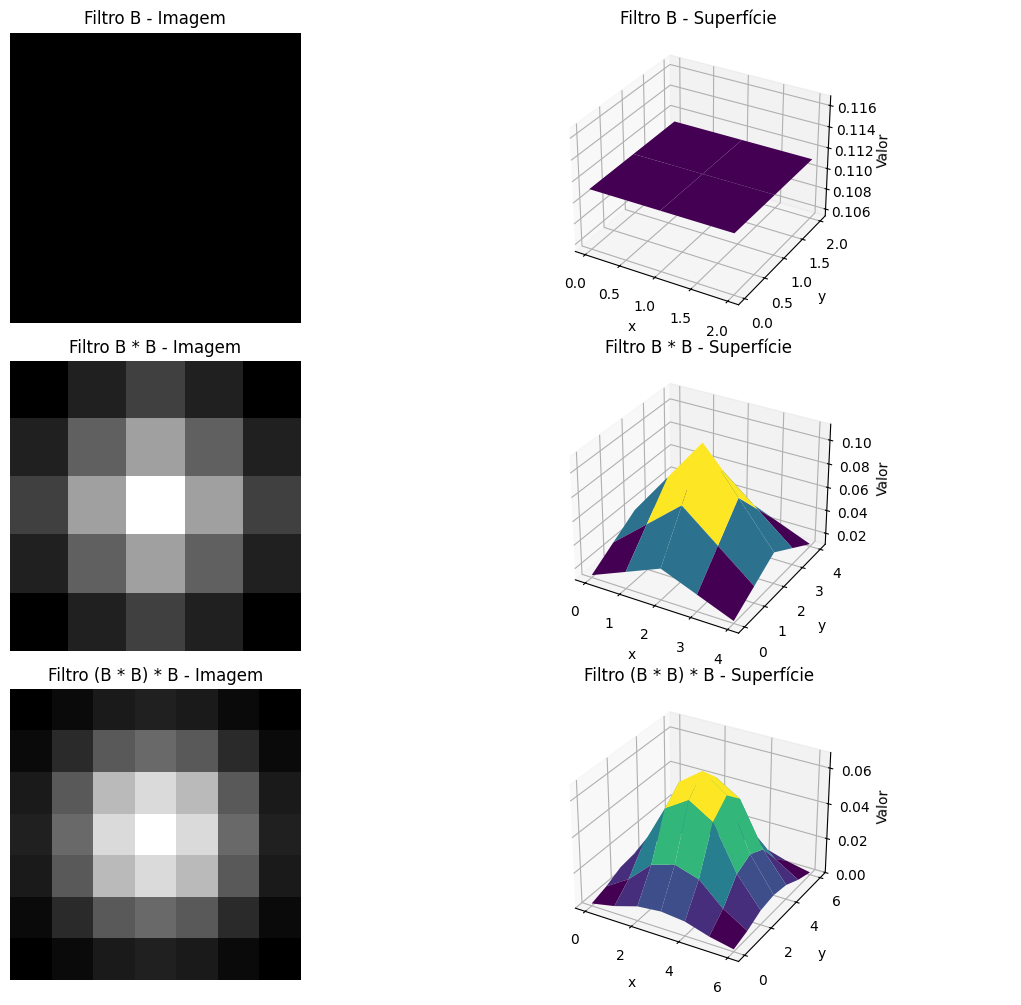

In [58]:
filtros = [B, B2, B3]
titulos = ['Filtro B', 'Filtro B * B', 'Filtro (B * B) * B']

fig_q5_i4, axs = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))

for i, filtro in enumerate(filtros):
    axs[i, 0].imshow(filtro, cmap='gray', interpolation='nearest')
    axs[i, 0].set_title(f'{titulos[i]} - Imagem')
    axs[i, 0].axis('off')
    axs[i, 1].axis('off')

    ax3d = fig_q5_i4.add_subplot(3, 2, 2*i + 2, projection='3d')
    x = np.arange(filtro.shape[1])
    y = np.arange(filtro.shape[0])
    x, y = np.meshgrid(x, y)
    ax3d.plot_surface(x, y, filtro, cmap='viridis')
    ax3d.set_title(f'{titulos[i]} - Superfície')
    ax3d.set_xlabel('x')
    ax3d.set_ylabel('y')
    ax3d.set_zlabel('Valor')

fig_q5_i4.tight_layout()
fig_q5_i4.savefig(path_assets / "atv02-q05-04.png", dpi=400, bbox_inches='tight')
plt.show()

# Questão 06

In [81]:
imagem = np.array([
    [1, 3, 0],
    [2, 2, 3],
    [1, 3, 1]
], dtype=float)

imagem_filtrada = convolve2d(imagem, B, mode='same', boundary='fill', fillvalue=0)

imagem_quantizada = np.round(np.clip(imagem_filtrada, 0, 15))

In [83]:
imagem_filtrada

array([[0.88888889, 1.22222222, 0.88888889],
       [1.33333333, 1.77777778, 1.33333333],
       [0.88888889, 1.33333333, 1.        ]])

In [84]:
imagem_quantizada

array([[1., 1., 1.],
       [1., 2., 1.],
       [1., 1., 1.]])

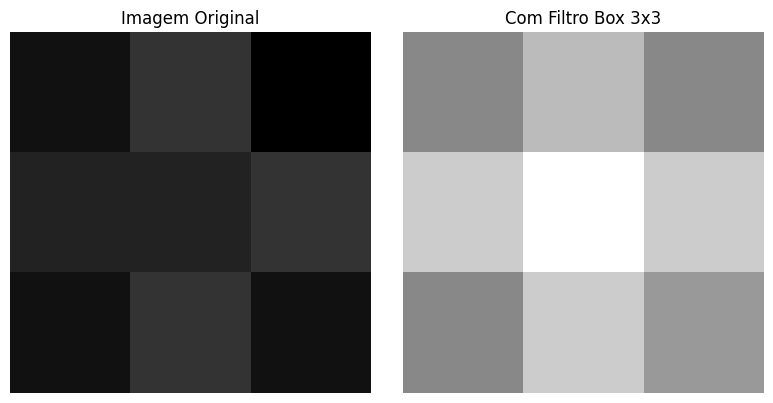

In [77]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].imshow(imagem, cmap='gray', vmin=0, vmax=15)
axs[0].set_title('Imagem Original')
axs[0].axis('off')

axs[1].imshow(imagem_quantizada, cmap='gray', vmin=0, vmax=15)
axs[1].set_title('Com Filtro Box 3x3')
axs[1].axis('off')

plt.tight_layout()
plt.show()
